# KAN 可符号化实验（symkan 重构版）

本 notebook 对应论文中的完整实验链路，目标是同时获得：
- 可接受的分类性能（accuracy / AUC）
- 可解释的符号表达式（分层函数库 + 逐层符号化）
- 可复现的性能基准（耗时/内存/并行策略）

## 实验主线
1. 数据读取与设备统一
2. baseline KAN 与输入归因筛选
3. 分阶段稀疏训练（stagewise）
4. 分层符号化导出（含低风险提速开关）
5. 数值验证 + ROC/AUC + 结构化导出
6. 速度与内存基准（含多轮统计）

## 关键原则
- 符号化采用**分层策略**，不跨层联合拟合。
- 默认优先稳定性，再通过并行与门控参数提升速度。
- 所有核心结果均导出为 CSV，便于论文复用。

In [1]:
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sympy as sp
import torch
from sklearn.metrics import accuracy_score

warnings.filterwarnings('ignore')
np.random.seed(123)
torch.manual_seed(123)

from kan import KAN

# notebook 初始设备（后续在 symkan 初始化单元中再归一化）
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device =', device)

device = cpu


## 1) 数据读取与任务定义

- 优先读取本地：`X_train/X_test` 与 `Y_train_cat/Y_test_cat`。
- 若本地文件缺失，自动按 SymbolNet 思路获取 MNIST 并预处理后落盘。
- 自动兼容 one-hot 与类别索引标签格式。
- 输出统一得到 `n_classes` 与 `input_dim`，作为后续建模参数。

In [2]:
from pathlib import Path
import numpy as np
from sklearn.datasets import fetch_openml


def _select_classes(x, y, classes):
    mask = np.zeros_like(y, dtype=bool)
    for c in classes:
        mask |= (y == c)
    return x[mask], y[mask]


def _onehot_from_labels(y, classes):
    classes = sorted(set(int(v) for v in classes))
    mapping = {c: i for i, c in enumerate(classes)}
    idx = np.array([mapping[int(v)] for v in y], dtype=np.int64)
    return np.eye(len(classes), dtype=np.float32)[idx]


def _fetch_mnist_symbolnet_style(classes):
    # 优先使用 SymbolNet 的 keras.mnist 路径；不可用时回退到 openml。
    try:
        from tensorflow import keras  # type: ignore
        (x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
        x_train = x_train.reshape(x_train.shape[0], -1).astype(np.float32) / 255.0
        x_test = x_test.reshape(x_test.shape[0], -1).astype(np.float32) / 255.0
        y_train = y_train.astype(np.int64)
        y_test = y_test.astype(np.int64)
        source = 'tensorflow.keras.datasets.mnist'
    except Exception:
        mnist = fetch_openml('mnist_784', version=1, as_frame=False)
        x = mnist.data.astype(np.float32) / 255.0
        y = mnist.target.astype(np.int64)
        x_train, x_test = x[:60000], x[60000:]
        y_train, y_test = y[:60000], y[60000:]
        source = 'sklearn.fetch_openml(mnist_784)'

    x_train, y_train = _select_classes(x_train, y_train, classes)
    x_test, y_test = _select_classes(x_test, y_test, classes)
    y_train_oh = _onehot_from_labels(y_train, classes)
    y_test_oh = _onehot_from_labels(y_test, classes)
    return x_train, x_test, y_train_oh, y_test_oh, source


x_train_path = Path('X_train.npy')
x_test_path = Path('X_test.npy')
y_train_path = Path('Y_train_cat.npy')
y_test_path = Path('Y_test_cat.npy')

if all(p.exists() for p in [x_train_path, x_test_path, y_train_path, y_test_path]):
    X_train = np.load(x_train_path).astype(np.float32)
    X_test = np.load(x_test_path).astype(np.float32)
    Y_train_raw = np.load(y_train_path)
    Y_test_raw = np.load(y_test_path)
    print('已从本地加载 npy 数据文件。')
else:
    classes = list(range(10))
    X_train, X_test, Y_train_raw, Y_test_raw, source = _fetch_mnist_symbolnet_style(classes)
    np.save(x_train_path, X_train.astype(np.float32))
    np.save(x_test_path, X_test.astype(np.float32))
    np.save(y_train_path, Y_train_raw.astype(np.float32))
    np.save(y_test_path, Y_test_raw.astype(np.float32))
    print(f'检测到缺失数据文件，已自动生成并保存（source={source}, classes={classes}）。')

if Y_train_raw.ndim > 1:
    y_train = np.argmax(Y_train_raw, axis=1).astype(np.int64)
    y_test = np.argmax(Y_test_raw, axis=1).astype(np.int64)
    n_classes = int(Y_train_raw.shape[1])
else:
    y_train = Y_train_raw.astype(np.int64)
    y_test = Y_test_raw.astype(np.int64)
    n_classes = int(np.max(y_train) + 1)

Y_train = np.eye(n_classes, dtype=np.float32)[y_train]
Y_test = np.eye(n_classes, dtype=np.float32)[y_test]

input_dim = X_train.shape[1]
print(f'X_train: {X_train.shape}  Y_train: {Y_train.shape}')
print(f'X_test : {X_test.shape}   Y_test : {Y_test.shape}')
print(f'n_classes = {n_classes}, input_dim = {input_dim}')

检测到缺失数据文件，已自动生成并保存（source=tensorflow.keras.datasets.mnist, classes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]）。
X_train: (60000, 784)  Y_train: (60000, 10)
X_test : (10000, 784)   Y_test : (10000, 10)
n_classes = 10, input_dim = 784


## 2) 运行时与基础工具初始化

本节完成：
- `symkan` 分层 API 导入
- 设备归一化（CPU/CUDA）
- 批大小策略统一（`default_batch_size`）

说明：后续所有训练、符号化与评估都复用这里的运行时配置。

In [3]:
# 使用分层后的 symkan API
import importlib
import symkan.core.runtime as core_runtime
importlib.reload(core_runtime)

from symkan.core import (
    set_device,
    get_device,
    build_dataset,
    model_logits,
    model_acc,
    model_acc_ds,
    get_n_edge,
    safe_fit,
)
from symkan.pruning import safe_attribute

resolve_device = core_runtime.resolve_device
default_batch_size = core_runtime.default_batch_size

# 归一化设备并同步到 symkan 运行时
device = str(resolve_device(device))
set_device(device)
BATCH_SIZE = default_batch_size()

print('symkan.core/pruning 已加载 ✓')
print('当前设备 =', get_device())
print('BATCH_SIZE =', BATCH_SIZE)

symkan.core/pruning 已加载 ✓
当前设备 = cpu
BATCH_SIZE = 64


## 3) 训练与符号化组件准备

加载三类核心组件：
- `tuning`：阶段训练与模型选择
- `symbolic`：分层符号化与表达式处理
- `eval/io`：数值验证、AUC 与报表导出

从本节开始进入可执行实验主流程。

In [4]:
# 使用 symkan.tuning 的分阶段训练模块
from symkan.tuning import sym_readiness_score, stagewise_train

print('stagewise_train 已从 symkan.tuning 加载 ✓')
print('sym_readiness_score 已从 symkan.tuning 加载 ✓')

stagewise_train 已从 symkan.tuning 加载 ✓
sym_readiness_score 已从 symkan.tuning 加载 ✓


In [5]:
# 使用 symkan.symbolic / symkan.eval / symkan.io
from symkan.symbolic import (
    symbolize_pipeline,
    format_expr,
    LIB_HIDDEN,
    LIB_OUTPUT,
    collect_all_formulas,
)
from symkan.eval import (
    validate_formula_numerically,
    compute_multiclass_roc_auc,
    plot_roc_curves,
)
from symkan.io import save_symbolic_summary

# 保留 notebook 历史变量名兼容
_LIB_HIDDEN = LIB_HIDDEN
_LIB_OUTPUT = LIB_OUTPUT

print('='*60)
print('symbolic/eval/io 已切换到分层 API ✓')
print(f'  _LIB_HIDDEN = {_LIB_HIDDEN}')
print(f'  _LIB_OUTPUT = {_LIB_OUTPUT}')

symbolic/eval/io 已切换到分层 API ✓
  _LIB_HIDDEN = ['x', 'x^2', 'tanh']
  _LIB_OUTPUT = ['x', 'x^2']


## 4) Baseline KAN（对照组）

目标：给出未强化流程下的基准精度与边数。
- 采用较窄网络与 `grid=5`，保证后续符号化可行。
- 该结果用于与增强模型、符号化模型做公平对比。

In [6]:
dataset_full = build_dataset(X_train, Y_train, X_test, Y_test)

# 网络结构：两层
inner_dim = 16  # 可调：过小可能无法拟合，过大可能导致符号化失败
width_base = [input_dim, inner_dim, n_classes]

base_model = KAN(
    width=width_base, grid=5, k=3, seed=123,
    auto_save=False, symbolic_enabled=True, save_act=True, device=device,
)

base_res = safe_fit(
    base_model, dataset_full,
    opt='Adam', steps=150, lr=0.02, lamb=1e-4,
    batch=BATCH_SIZE, update_grid=True, singularity_avoiding=True, log=12,
)

base_acc = model_acc(base_model, X_test, y_test)
print(f'\nBaseline KAN test accuracy = {base_acc:.4f}')
print(f'Baseline n_edge = {get_n_edge(base_model)}')

| train_loss: 1.76e-01 | test_loss: 1.70e-01 | reg: 1.35e+02 | : 100%|█| 150/150 [00:10<00:00, 13.95



Baseline KAN test accuracy = 0.8489
Baseline n_edge = 12704


## 5) 归因式输入筛选（降维）

目标：在精度可控前提下减少输入维度，提高符号化稳定性与速度。
- 使用 `safe_attribute` 计算特征贡献。
- 保留 top-K 特征并重建训练/测试数据集。
- 该步骤通常显著影响后续符号化耗时。

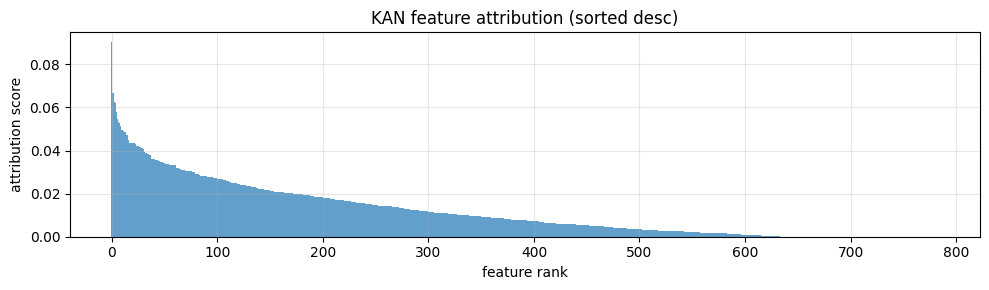

输入维度: 784 → 120
保留特征的最低归因分数: 0.03003
保留索引（前20）: [151, 152, 153, 155, 156, 182, 183, 209, 210, 211, 212, 236, 237, 238, 239, 240, 241, 242, 243, 264]...
dataset_enhanced train shape: (60000, 120)
dataset_enhanced test shape:  (10000, 120)


In [7]:
# 【关键】先刷新归因分数
feature_score = safe_attribute(base_model, dataset_full)

# 可视化
plt.figure(figsize=(10, 3))
plt.title('KAN feature attribution (sorted desc)')
sorted_scores = np.sort(feature_score)[::-1]
plt.bar(range(len(sorted_scores)), sorted_scores, width=1.0, alpha=0.7)
plt.xlabel('feature rank')
plt.ylabel('attribution score')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── 选择保留的输入特征（top-K） ──
# KAN 符号化对维度极为敏感，过多会导致符号化失败，过少又可能丢失重要信息。
# 这里在精度和可符号化之间取折中，当然这也跟mnist分类任务有效像素有关
top_k = 120  # 可调：越小越容易符号化，但精度越低，越大速度越慢，但精度高
keep_idx = np.sort(np.argsort(-feature_score)[:top_k])

print(f'输入维度: {input_dim} → {len(keep_idx)}')
print(f'保留特征的最低归因分数: {feature_score[keep_idx[-1]]:.5f}')
print(f'保留索引（前20）: {keep_idx.tolist()[:20]}...')

# ── 构建降维后的数据集 ──
X_train_sel = X_train[:, keep_idx]
X_test_sel  = X_test[:, keep_idx]
dataset_enhanced = build_dataset(X_train_sel, Y_train, X_test_sel, Y_test)

print(f'dataset_enhanced train shape: {X_train_sel.shape}')
print(f'dataset_enhanced test shape:  {X_test_sel.shape}')

## 6) 增强模型训练（阶段稀疏化 + 渐进剪枝）

目标：得到“精度-稀疏度”折中最优的候选模型。
- 通过 `stagewise_train` 在多个阶段中自动选择得分最优快照。
- 输出 `selected_stage/selected_score` 作为后续符号化入口。

In [8]:
sel_dim = dataset_enhanced['train_input'].shape[1]
width_enh = [sel_dim, inner_dim, n_classes]
print(f'Enhanced KAN 结构: {width_enh}  (grid=5, k=3)')
print(f'理论满连接边数: {sel_dim*inner_dim + inner_dim*n_classes}')

# 启发式评分选择 + 自适应符号化
enhanced_model, enhanced_res = stagewise_train(
    dataset_enhanced, width=width_enh,
    grid=5, k=3, seed=42,
    # 更多更细的稀疏化阶段（10 个 stage，λ 缓慢递增）
    lamb_schedule=(0.0, 0.0, 2e-5, 5e-5, 1e-4, 2e-4, 3e-4, 5e-4, 7e-4, 1e-3),
    lr_schedule  =(0.02, 0.015, 0.012, 0.01, 0.008, 0.006, 0.005, 0.004, 0.003, 0.002),
    steps_per_stage=60,
    batch_size=BATCH_SIZE,
    prune_start_stage=3,          # 前 3 个 stage 只训练不剪枝
    target_edges=120,              # 放宽目标，给符号化更多余量
    prune_edge_threshold_init=0.003,  # 从非常小的阈值开始
    prune_edge_threshold_step=0.003,  # 每次小幅递增
    prune_acc_drop_tol=0.04,      # 容忍 4% 精度下降
    post_prune_ft_steps=50,       # 每次剪枝后微调 50 步
    sym_target_edges=50,          # 符号化目标边数（用于评分）
    acc_weight=0.5,               # 精度权重 ，稀疏度权重 = 1 - acc_weight
    verbose=True,
 )

enhanced_acc = model_acc_ds(enhanced_model, dataset_enhanced)
print(f'\nEnhanced KAN test accuracy = {enhanced_acc:.4f}')
print(f'Enhanced n_edge = {get_n_edge(enhanced_model)}')
print(f'Selected stage = {enhanced_res["selected_stage"]}')
print(f'Selected score = {enhanced_res["selected_score"]:.3f}')

# 显示所有 stage 的评分排名
stage_df = pd.DataFrame(enhanced_res['stage_logs'])
display(stage_df)

# v4: 评分排名可视化
print(f'\n所有 stage 综合评分排名:')
snapshots_info = [
    {'stage': s['stage'], 'acc': s['acc'], 'edges': s['n_edges'], 'score': s['score']}
    for s in enhanced_res['stage_snapshots']
]
rank_df = pd.DataFrame(snapshots_info).sort_values('score', ascending=False)
display(rank_df)

Enhanced KAN 结构: [120, 16, 10]  (grid=5, k=3)
理论满连接边数: 2080


| train_loss: 1.54e-01 | test_loss: 1.79e-01 | reg: 0.00e+00 | : 100%|█| 60/60 [00:01<00:00, 45.01it


[stage 0] λ=0.0e+00 lr=0.0200  acc 0.1084→0.8345  edges 2080→2080  score=0.429  prune=✗  


| train_loss: 1.76e-01 | test_loss: 1.79e-01 | reg: 0.00e+00 | : 100%|█| 60/60 [00:01<00:00, 58.23it


[stage 1] λ=0.0e+00 lr=0.0150  acc 0.8345→0.8639  edges 2080→2080  score=0.444  prune=✗  


...

| train_loss: 1.87e-01 | test_loss: 1.50e-01 | reg: 0.00e+00 | : 100%|█| 60/60 [00:00<00:00, 62.77it



──────────────────────────────────────────────────
模型选择（sym_readiness_score, acc_weight=0.5）:
  精度下限: 0.5773 (max_acc=0.8882 × 0.65)
  候选数量: 11/11
  ▸ 选中 stage=9, acc=0.8182, edges=116, score=0.625

Enhanced KAN test accuracy = 0.8182
Enhanced n_edge = 116
Selected stage = 9
Selected score = 0.625


,stage,lamb,lr,acc_before,acc_after,edges_before,edges_after,prune_accepted,rollback,prune_th,sym_score
0,0,0.00000,0.020,0.1084,0.8345,2080,2080,False,,0.003,0.429269
1,1,0.00000,0.015,0.8345,0.8639,2080,2080,False,,0.003,0.443969
2,2,0.00002,0.012,0.8639,0.8763,2080,2080,False,,0.003,0.450169
3,3,0.00005,0.010,0.8763,0.8882,2080,979,True,,0.006,0.469636
4,4,0.00010,0.008,0.8882,0.8849,979,523,True,,0.009,0.490251
5,5,0.00020,0.006,0.8849,0.8709,523,314,True,,0.012,0.515068
6,6,0.00030,0.005,0.8709,0.8593,314,223,True,,0.015,0.541758
7,7,0.00050,0.004,0.8593,0.8483,223,181,True,,0.018,0.562272
8,8,0.00070,0.003,0.8483,0.8327,181,139,True,,0.021,0.596206
9,9,0.00100,0.002,0.8327,0.8182,139,116,True,,0.024,0.624617



所有 stage 综合评分排名:


,stage,acc,edges,score
9,9,0.8182,116,0.624617
10,final,0.8179,116,0.624467
8,8,0.8327,139,0.596206
7,7,0.8483,181,0.562272
6,6,0.8593,223,0.541758
5,5,0.8709,314,0.515068
4,4,0.8849,523,0.490251
3,3,0.8882,979,0.469636
2,2,0.8763,2080,0.450169
1,1,0.8639,2080,0.443969


## 7) 训练结果可视化与摘要

本节用于快速检查训练质量：
- baseline vs enhanced 的损失曲线
- 阶段边数变化
- 核心指标摘要表（精度、边数）

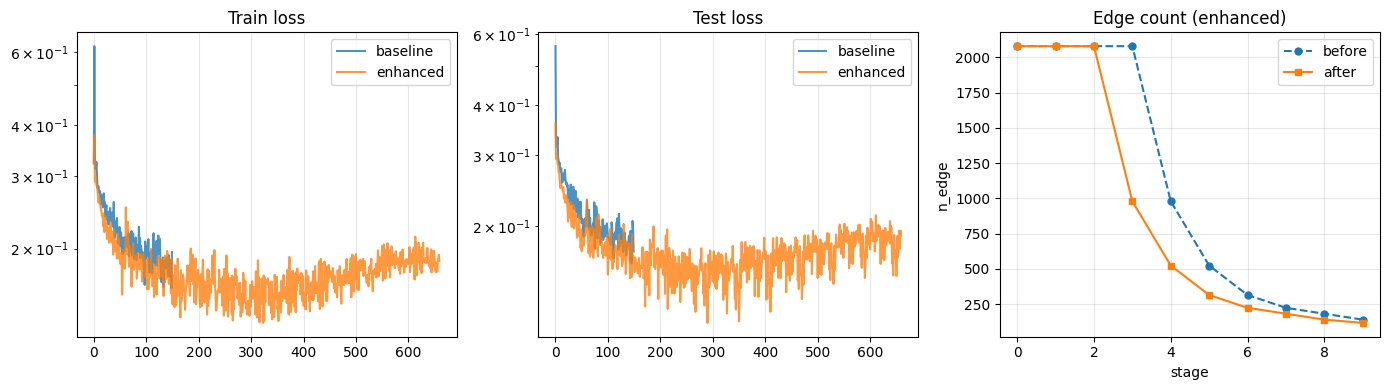

,model,input_dim,test_acc,n_edge,best_acc
0,baseline_kan,784,0.8489,12704,NaN
1,enhanced_kan,120,0.8182,116,0.8182


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Loss curves
ax = axes[0]
ax.set_title('Train loss')
if 'train_loss' in base_res:
    ax.plot(base_res['train_loss'], label='baseline', alpha=0.8)
ax.plot(enhanced_res['train_loss'], label='enhanced', alpha=0.8)
ax.set_yscale('log')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.set_title('Test loss')
if 'test_loss' in base_res:
    ax.plot(base_res['test_loss'], label='baseline', alpha=0.8)
ax.plot(enhanced_res['test_loss'], label='enhanced', alpha=0.8)
ax.set_yscale('log')
ax.legend(); ax.grid(alpha=0.3)

# Edge count per stage
ax = axes[2]
ax.set_title('Edge count (enhanced)')
if len(stage_df) > 0:
    ax.plot(stage_df['stage'], stage_df['edges_before'], 'o--', label='before', ms=5)
    ax.plot(stage_df['stage'], stage_df['edges_after'], 's-', label='after', ms=5)
    ax.legend(); ax.grid(alpha=0.3)
    ax.set_xlabel('stage')
    ax.set_ylabel('n_edge')

plt.tight_layout()
plt.show()

# 汇总表
summary = pd.DataFrame([
    {
        'model': 'baseline_kan',
        'input_dim': int(input_dim),
        'test_acc': float(base_acc),
        'n_edge': get_n_edge(base_model),
    },
    {
        'model': 'enhanced_kan',
        'input_dim': int(enhanced_model.width_in[0]) if hasattr(enhanced_model, 'width_in') else '?',
        'test_acc': float(enhanced_acc),
        'n_edge': get_n_edge(enhanced_model),
        'best_acc': float(enhanced_res.get('best_acc', enhanced_acc)),
    }
])
summary

## 8) 符号化导出（主实验）

本节是核心导出流程：
1. 渐进剪枝（边数收缩）
2. 逐层符号拟合（不跨层）
3. 层间/全局微调（含低风险提速开关）
4. 表达式收集与统计输出

关键观察项：
- `final_acc`、`final_n_edge`
- `sym_stats`（活跃边/fix/低R²）
- `timing`（symbolic_total_seconds 与 layer times）

In [10]:
print('='*60)
print('符号化导出 — 强制全符号化 + 数值安全函数库 + 分层')
print('='*60)
print(f'选中模型: stage={enhanced_res["selected_stage"]}, '
      f'边数={get_n_edge(enhanced_model)}, '
      f'精度={enhanced_acc:.4f}, '
      f'评分={enhanced_res["selected_score"]:.3f}')

t0 = time.time()
export_result = symbolize_pipeline(
    enhanced_model, dataset_enhanced,
    target_edges=90,              # 符号化目标边数，过高可能导致符号化失败，过低可能过度简化，需根据实际情况调整
    max_prune_rounds=30,
    lib=None,                       # 不指定统一库，使用分层库
    lib_hidden=_LIB_HIDDEN,         # 输入→隐藏层
    lib_output=_LIB_OUTPUT,         # 隐藏→输出层
    weight_simple=0.10,             # weight_simple×复杂度 + (1-weight_simple)×R²损失，weight越大越偏好简单函数
    finetune_steps=50,              # 稀疏化微调50步
    finetune_lr=0.0005,             # 稀疏化微调学习率
    layerwise_finetune_steps=120,   # 每层符号化后 120 步层间微调
    affine_finetune_steps=200,      # 200 步强化微调，补偿全符号化精度损失
    affine_finetune_lr_schedule=[0.003, 0.001, 0.0005, 0.0002],  # 强化微调学习率逐步降低
    parallel_mode='auto',           # auto: CPU并行建议，CUDA默认串行
    parallel_workers=None,          # None时自动推断
    parallel_min_tasks=16,          # 任务数不足时退回串行，避免并行开销
    # 低风险提速：剪枝阶段评估门控 + 归因采样分级 + 强化微调早停
    prune_eval_interval=2,                  # 每2轮评估一次，接近目标边数时自动恢复逐轮评估
    prune_attr_sample_adaptive=True,
    prune_attr_sample_min=768,
    prune_attr_sample_max=2048,
    heavy_ft_early_stop_patience=2,         #若连续 patience 次提升小于 min_delta，提前结束后续重微调步骤
    heavy_ft_early_stop_min_delta=5e-4,
    collect_timing=True,                    # 返回分阶段耗时统计
    batch_size=BATCH_SIZE,
    verbose=True,
 )
export_time = time.time() - t0

export_model    = export_result['model']
export_formulas = export_result['formulas']
valid_exprs     = export_result['valid_expressions']
export_trace    = export_result['trace']
sym_stats       = export_result['sym_stats']
timing_stats    = export_result.get('timing', {})

print(f'\n导出完成 (耗时 {export_time:.1f}s)')
print(f'输入边数: {export_result.get("input_n_edge", "N/A")} → '
      f'自适应目标: {export_result.get("effective_target_edges", "N/A")} → '
      f'最终边数: {export_result["final_n_edge"]}')
print(f'符号化后精度: {export_result.get("final_acc", "N/A")}')

input_dim_before = int(dataset_enhanced['train_input'].shape[1])
effective_input_dim = int(export_result.get('effective_input_dim', input_dim_before))
compress_ratio = (1.0 - effective_input_dim / max(1, input_dim_before)) * 100.0
print(f'有效输入维度: {effective_input_dim}/{input_dim_before}')
print(f'输入压缩比例: {compress_ratio:.2f}%')

print(f'符号化统计: 活跃边 {sym_stats.get("total",0)}, '
      f'fix成功 {sym_stats.get("fixed",0)}, '
      f'低R²强制fix {sym_stats.get("low_r2",0)}')
print(f'有效表达式数量: {len(valid_exprs)}')
print(f'并行suggest workers: {sym_stats.get("parallel_workers", 1)}')

if timing_stats:
    print('\n耗时统计摘要:')
    print(f"  - symbolic_total_seconds = {timing_stats.get('symbolic_total_seconds', 'N/A')}")
    if timing_stats.get('symbolic_layers'):
        print('  - layer times:')
        for rec in timing_stats['symbolic_layers'][:6]:
            print(f"    layer={rec['layer']}, active={rec['active']}, fixed={rec['fixed']}, t={rec['seconds']:.3f}s, workers={rec['workers']}")

# 显示 R² 分布
r2_recs = sym_stats.get('r2_records', [])
if r2_recs:
    r2_vals = [r['r2'] for r in r2_recs]
    print(f'\n逐边 R² 分布:')
    print(f'  min={min(r2_vals):.4f}, median={np.median(r2_vals):.4f}, max={max(r2_vals):.4f}')
    n_low = sum(1 for v in r2_vals if v < 0.5)
    print(f'  R² < 0.5 (低R²强制fix): {n_low}/{len(r2_vals)}')
    from collections import Counter
    name_counts = Counter(r['name'] for r in r2_recs)
    print(f'  函数分布: {dict(name_counts)}')

if len(export_trace) > 0:
    print('\n剪枝轨迹:')
    display(export_trace)

if len(valid_exprs) == 0:
    print('\n⚠ 未找到非零/非常数表达式。可尝试：')
    print('  - 增大 target_edges（减少剪枝）')
    print('  - 扩充候选函数库')
else:
    print(f'\n{"="*60}')
    print('导出的符号表达式（系数已截断为2位有效数字，原始全精度保存在 valid_exprs 中）')
    print(f'{"="*60}')
    for item in valid_exprs[:10]:
        print(f'\nexpr_{item["index"]} (complexity = {item["complexity"]}):')
        s_display = format_expr(item['expr'], n_digits=2)
        print(f'  {s_display[:300]}{"..." if len(s_display) > 300 else ""}')
        print('-'*50)
    if len(valid_exprs) > 10:
        print(f'\n... 还有 {len(valid_exprs)-10} 个表达式未显示')

符号化导出 — 强制全符号化 + 数值安全函数库 + 分层
选中模型: stage=9, 边数=116, 精度=0.8182, 评分=0.625


| train_loss: 2.00e-01 | test_loss: 2.07e-01 | reg: 0.00e+00 | : 100%|█| 50/50 [00:00<00:00, 63.23it
| train_loss: 1.92e-01 | test_loss: 2.05e-01 | reg: 0.00e+00 | : 100%|█| 50/50 [00:00<00:00, 64.46it
| train_loss: 1.81e-01 | test_loss: 2.09e-01 | reg: 0.00e+00 | : 100%|█| 50/50 [00:00<00:00, 64.59it
| train_loss: 1.90e-01 | test_loss: 1.82e-01 | reg: 0.00e+00 | : 100%|█| 50/50 [00:00<00:00, 61.29it
| train_loss: 1.98e-01 | test_loss: 2.02e-01 | reg: 0.00e+00 | : 100%|█| 50/50 [00:00<00:00, 65.16it
| train_loss: 2.12e-01 | test_loss: 1.95e-01 | reg: 0.00e+00 | : 100%|█| 50/50 [00:00<00:00, 62.44it
| train_loss: 1.98e-01 | test_loss: 2.07e-01 | reg: 0.00e+00 | : 100%|█| 50/50 [00:00<00:00, 64.58it
| train_loss: 2.23e-01 | test_loss: 2.03e-01 | reg: 0.00e+00 | : 100%|█| 50/50 [00:00<00:00, 60.70it
| train_loss: 1.78e-01 | test_loss: 1.84e-01 | reg: 0.00e+00 | : 100%|█| 50/50 [00:00<00:00, 62.95it
| train_loss: 2.08e-01 | test_loss: 1.91e-01 | reg: 0.00e+00 | : 100%|█| 50/50 [00:00<00:00

[symbolize_pipeline] 输入压缩: 120 -> 53


| train_loss: 1.93e-01 | test_loss: 2.06e-01 | reg: 0.00e+00 | : 100%|█| 100/100 [00:01<00:00, 79.23


  Layer 0: 活跃=71, fix=71


...

    ⚠ 低R² fix (1,2,5) → x^2  R²=0.4924
  Layer 1: 活跃=19, fix=19
  函数分布: {'tanh': 53, 'x^2': 33, 'x': 4}


| train_loss: 2.16e-01 | test_loss: 2.32e-01 | reg: 0.00e+00 | : 100%|█| 50/50 [00:12<00:00,  3.86it
| train_loss: 2.22e-01 | test_loss: 1.98e-01 | reg: 0.00e+00 | : 100%|█| 50/50 [00:12<00:00,  3.92it
| train_loss: 2.25e-01 | test_loss: 2.20e-01 | reg: 0.00e+00 | : 100%|█| 50/50 [00:12<00:00,  3.99it
| train_loss: 2.15e-01 | test_loss: 2.10e-01 | reg: 0.00e+00 | : 100%|█| 50/50 [00:12<00:00,  4.07it



导出完成 (耗时 134.8s)
输入边数: 116 → 自适应目标: 90 → 最终边数: 90
符号化后精度: 0.7700999975204468
有效输入维度: 53/120
输入压缩比例: 55.83%
符号化统计: 活跃边 90, fix成功 90, 低R²强制fix 1
有效表达式数量: 10
并行suggest workers: 1

耗时统计摘要:
  - symbolic_total_seconds = 50.32898930000002
  - layer times:
    layer=0, active=71, fixed=71, t=17.627s, workers=1
    layer=1, active=19, fixed=19, t=3.359s, workers=1

逐边 R² 分布:
  min=0.4924, median=0.9877, max=1.0000
  R² < 0.5 (低R²强制fix): 1/90
  函数分布: {'tanh': 53, 'x^2': 33, 'x': 4}

剪枝轨迹:


,round,threshold,edges_before,edges_after,acc
0,0,0.020000,116,114,0.8141
1,1,0.020345,114,111,0.8110
2,2,0.020690,111,110,0.8127
3,3,0.021034,110,106,0.8080
4,4,0.021379,106,104,0.8105
5,5,0.021724,104,102,0.8090
6,6,0.022069,102,100,0.8061
7,7,0.022414,100,100,0.8061
8,8,0.022759,100,100,0.8061
9,9,0.023103,100,100,0.8061



导出的符号表达式（系数已截断为2位有效数字，原始全精度保存在 valid_exprs 中）

expr_0 (complexity = 99):
  260*(0.0032*(0.0016 - x_16)**2 - 0.0013*(0.89 - x_30)**2 - 0.01*(1 - 0.74*x_26)**2 + 0.32*tanh(0.34*x_20 - 2) + 0.15*tanh(1.1*x_28 + 1.6) + 0.4*tanh(1.9*x_31 + 2.1) - 0.6*tanh(3.6*x_33 + 2.2) + 0.0089*tanh(3.6*x_36 - 0.47) + 0.022*tanh(1.3*x_43 + 0.64) - 0.5*tanh(2.2*x_50 + 2.3) - 0.18*tanh(3.8*x_52...
--------------------------------------------------

expr_1 (complexity = 49):
  140*(-0.026*x_30 + tanh(4.1*x_12 + 2.3) - 0.86*tanh(0.61*x_19 + 1.9) + 0.15*tanh(0.58*x_27 + 1) + 0.14*tanh(0.61*x_28 + 1) + 0.058*tanh(10*x_47 + 0.61) - 0.44)**2 - 0.054
--------------------------------------------------

expr_2 (complexity = 66):
  14*(-0.034*(1 - 0.5*x_14)**2 + 0.15*(-0.55*x_17 - 1)**2 + 0.3*tanh(3.7*x_18 + 1.6) + 0.05*tanh(1.2*x_21 - 0.057) + 0.012*tanh(1.8*x_22 - 0.94) - 0.066*tanh(10*x_3 + 0.65) - tanh(2*x_44 + 2.1) + 0.47)**2 - 0.099
--------------------------------------------------

expr_3 (complexity = 125):

## 9) 公式一致性验证 + ROC/AUC + 汇总表

本节用于回答三个论文问题：
1. 公式是否与模型 forward 数值一致（R²）？
2. 符号化后分类能力是否可接受（AUC/Accuracy）？
3. 每类最终表达式复杂度如何（复杂度 + AUC 对照）？

① 数值验证：sympy公式 vs KAN forward 输出


,index,r2,complexity,numerically_unstable
0,0,-0.769978,99,False
1,1,-0.250885,49,False
2,2,-1.277788,66,False
3,3,-0.756344,125,False
4,4,0.042952,81,False
5,5,-0.825123,359,False
6,6,-0.905718,49,False
7,7,0.025622,84,False
8,8,-0.614149,245,False
9,9,-1.664325,236,False



公式-模型一致性:
  平均 R² = -0.6996
  正 R² 平均 = 0.0343
  负 R² 数量 = 8/10

符号化模型测试精度: 0.7701
原始增强模型精度:   0.8182
精度变化:           -0.0481
精度保持率:         94.1%

△ 符号化后精度 0.70~0.80，基本可接受

② ROC/AUC 评估（符号化模型）


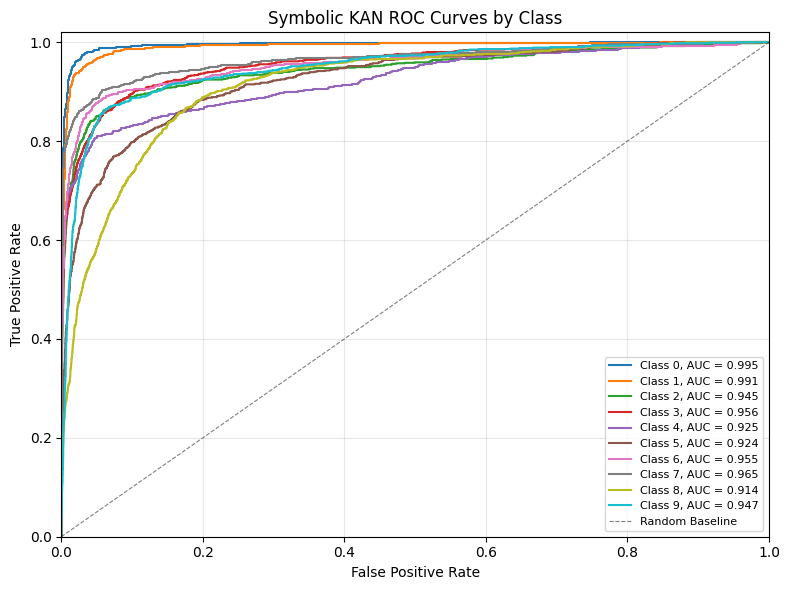


③ 符号回归汇总表


,类别,表达式,复杂度,AUC
0,0,260*(0.0032*(0.0016 - x_16)**2 - 0.0013*(0.89 - x_30)**2 - 0.01*(1 - 0.74*x_26)**2 + 0.32*tanh(0.34*x_20 - 2) + 0.15*tanh(1.1*x_28 + 1.6) + 0.4*tanh(1.9*x_31 + 2.1) - 0.6*tanh(3.6*x_33 + 2.2) + 0.0089*tanh(3.6*x_36 - 0.47) + 0.022*tanh(1.3*x_43 + 0.64) - 0.5*tanh(2.2*x_50 + 2.3) - 0.18*tanh(3.8*...,99,0.9948
1,1,140*(-0.026*x_30 + tanh(4.1*x_12 + 2.3) - 0.86*tanh(0.61*x_19 + 1.9) + 0.15*tanh(0.58*x_27 + 1) + 0.14*tanh(0.61*x_28 + 1) + 0.058*tanh(10*x_47 + 0.61) - 0.44)**2 - 0.054,49,0.9909
2,2,14*(-0.034*(1 - 0.5*x_14)**2 + 0.15*(-0.55*x_17 - 1)**2 + 0.3*tanh(3.7*x_18 + 1.6) + 0.05*tanh(1.2*x_21 - 0.057) + 0.012*tanh(1.8*x_22 - 0.94) - 0.066*tanh(10*x_3 + 0.65) - tanh(2*x_44 + 2.1) + 0.47)**2 - 0.099,66,0.9452
3,3,220*(-0.014*x_39 + 0.011*(1 - 0.63*x_45)**2 + 0.48*tanh(9.9*x_1 + 2.1) - tanh(0.85*x_12 + 2.1) + 0.85*tanh(2.2*x_15 + 2.2) - 0.59*tanh(0.54*x_43 + 1.8) + 0.25)**2 + 22*(0.025*(0.09 - x_40)**2 + 0.043*(0.17 - x_38)**2 + 0.037*(0.33 - x_37)**2 - 0.43*tanh(0.77*x_24 + 1.7) + 0.056*tanh(0.64*x_33 - ...,125,0.9558
4,4,130*(0.014*(1 - 0.65*x_23)**2 - 0.022*(1 - 0.32*x_46)**2 - 0.03*(1 - 0.43*x_7)**2 + tanh(0.73*x_13 + 2.1) + 0.3*tanh(0.82*x_3 + 1.4) - 0.97*tanh(1.7*x_32 + 2.3) - 0.38*tanh(3.8*x_33 + 2.2) + 0.046*tanh(1.3*x_6 + 0.8) + 0.011*tanh(1.6*x_8 - 1.1) + 0.059)**2 - 0.061,81,0.9249
5,5,-110*(-0.014*x_39 + 0.011*(1 - 0.63*x_45)**2 + 0.48*tanh(9.9*x_1 + 2.1) - tanh(0.85*x_12 + 2.1) + 0.85*tanh(2.2*x_15 + 2.2) - 0.59*tanh(0.54*x_43 + 1.8) + 0.24)**2 - 1.5*(-0.034*(1 - 0.5*x_14)**2 + 0.15*(-0.55*x_17 - 1)**2 + 0.3*tanh(3.7*x_18 + 1.6) + 0.05*tanh(1.2*x_21 - 0.057) + 0.012*tanh(1.8...,359,0.9242
6,6,1900*(-0.012*(1 - 0.29*x_15)**2 + 0.033*tanh(2.2*x_10 + 1) + 0.45*tanh(4.2*x_11 + 2.4) + 0.44*tanh(10*x_53 + 2.4) + 0.093*tanh(4.3*x_9 + 1.6) - 1)**2 - 0.058,49,0.9546
7,7,550*(0.0058*x_34 - 0.0039*(1 - 0.41*x_24)**2 + 0.0063*tanh(8.2*x_25 - 0.48) + 0.0052*tanh(1.6*x_27 - 1.4) + 0.0044*tanh(3.2*x_29 - 1.4) + 0.012*tanh(8.1*x_3 + 0.35) + 0.0042*tanh(10*x_35 - 0.21) + 0.25*tanh(0.82*x_41 + 2) + 0.44*tanh(10*x_5 + 2.2) + 0.31*tanh(2.3*x_51 + 2.3) - 1)**2 - 0.092,84,0.9649
8,8,-26*(0.024*(0.09 - x_40)**2 + 0.042*(0.17 - x_38)**2 + 0.037*(0.33 - x_37)**2 - 0.42*tanh(0.77*x_24 + 1.7) + 0.055*tanh(0.64*x_33 - 0.33) + 0.014*tanh(3*x_39 - 1.9) + 0.026*tanh(2.3*x_42 - 1.4) - 0.62*tanh(10*x_51 + 2.1) + 1)**2 - 470*(0.003*x_46 + 0.19*tanh(10*x_2 + 2.4) - 0.2*tanh(0.63*x_28 + ...,245,0.9142
9,9,1400*(0.003*x_46 + 0.19*tanh(10*x_2 + 2.4) - 0.2*tanh(0.63*x_28 + 2.1) + 0.11*tanh(3.2*x_3 + 2.1) + 0.0038*tanh(10*x_4 + 0.39) + 0.1*tanh(10*x_48 + 2.2) + 0.22*tanh(1.7*x_49 + 2.3) + 0.0053*tanh(10*x_5 + 0.38) + 0.56*tanh(4*x_51 + 2.5) - 1)**2 - 72*(0.014*(1 - 0.65*x_23)**2 - 0.022*(1 - 0.32*x_4...,236,0.9472



汇总表已保存至: kan_symbolic_summary.csv（expr_full 列保留全精度）
平均 AUC (macro)= 0.9517


In [11]:
# ═══════════════════════════════════════════════════════════════
# 公式数值验证 + ROC/AUC + 汇总表
# ═══════════════════════════════════════════════════════════════

from scipy.special import softmax as _softmax

# ── 1. 公式 vs 模型 R² 数值验证 ──
if len(valid_exprs) > 0:
    print('='*60)
    print('① 数值验证：sympy公式 vs KAN forward 输出')
    print('='*60)
    val_df = validate_formula_numerically(export_model, export_formulas, dataset_enhanced, n_sample=500)
    if val_df is not None and len(val_df) > 0:
        display(val_df)
        mean_r2 = val_df['r2'].mean()
        pos_r2 = val_df[val_df['r2'] > 0]['r2'].mean() if (val_df['r2'] > 0).any() else 0
        neg_count = (val_df['r2'] < 0).sum()
        unstable_count = val_df['numerically_unstable'].sum() if 'numerically_unstable' in val_df.columns else 0
        print(f'\n公式-模型一致性:')
        print(f'  平均 R² = {mean_r2:.4f}')
        print(f'  正 R² 平均 = {pos_r2:.4f}')
        print(f'  负 R² 数量 = {neg_count}/{len(val_df)}')
        if unstable_count > 0:
            print(f'  ⚠ 数值不稳定表达式: {unstable_count}/{len(val_df)}')
    else:
        print('数值验证未能完成（公式解析失败）')

# ── 2. 符号化模型测试精度 ──
sym_acc = model_acc_ds(export_model, dataset_enhanced)
print(f'\n符号化模型测试精度: {sym_acc:.4f}')
print(f'原始增强模型精度:   {enhanced_acc:.4f}')
print(f'精度变化:           {sym_acc - enhanced_acc:+.4f}')
print(f'精度保持率:         {sym_acc/enhanced_acc*100:.1f}%')

if sym_acc >= 0.80:
    print('\n✓ 符号化后精度 ≥ 0.80，达标')
elif sym_acc >= 0.70:
    print('\n△ 符号化后精度 0.70~0.80，基本可接受')
elif sym_acc >= enhanced_acc * 0.85:
    print(f'\n△ 精度保持率 ≥ 85%，可接受')
else:
    print('\n⚠ 符号化后精度偏低，建议：')
    print('  1. 调整 Topk和两次目标边数')
    print('  2. 调整 affine_finetune_steps')
    print('  3. 调整 layerwise_finetune_steps')


# ── 3. ROC/AUC 评估（基于符号化模型 forward） ──
print(f'\n{"="*60}')
print('② ROC/AUC 评估（符号化模型）')
print(f'{"="*60}')

# 获取符号化模型的 logits 并转为概率
logits_sym = model_logits(export_model, X_test_sel)
y_prob_sym = _softmax(logits_sym, axis=1)

# 获取 one-hot 测试标签
Y_test_sel = dataset_enhanced['test_label'].detach().cpu().numpy()

# 计算 per-class ROC/AUC
roc_data = compute_multiclass_roc_auc(Y_test_sel, y_prob_sym)

# 绘制 ROC 曲线
class_labels = [str(i) for i in range(n_classes)]
plot_roc_curves(roc_data, class_labels=class_labels,
                title='Symbolic KAN ROC Curves by Class')

# 输出 AUC 概览
auc_vals = [roc_data[c]['auc'] for c in range(n_classes)]
# print(f'\nROC Curves (Per Class):')
# for c in range(n_classes):
#     print(f'  Class {c}: AUC = {roc_data[c]["auc"]:.4f}')
# print(f'  Average AUC (macro): {np.mean(auc_vals):.4f}')

# ── 4. 汇总表：类别 | 表达式(2位有效数字) | 复杂度 | AUC ──
print(f'\n{"="*60}')
print('③ 符号回归汇总表')
print(f'{"="*60}')

# 收集所有类别的表达式（含零/常数）
all_formulas = collect_all_formulas(export_formulas)
# valid_exprs 用于匹配有效表达式
valid_idx_set = {v['index'] for v in valid_exprs}

summary_rows = []
for c in range(n_classes):
    formula_info = next((f for f in all_formulas if f['index'] == c), None)
    if formula_info and formula_info['index'] in valid_idx_set:
        expr_full = formula_info['expr']
        expr_display = format_expr(expr_full, n_digits=2)
        complexity = formula_info['complexity']
    else:
        expr_full = 'N/A (零或常数)'
        expr_display = 'N/A'
        complexity = 0

    auc_val = roc_data[c]['auc']
    summary_rows.append({
        '类别': c,
        '表达式': expr_display,
        '复杂度': complexity,
        'AUC': round(auc_val, 4),
        'expr_full': expr_full,
    })

summary_df = pd.DataFrame(summary_rows)

display_cols = ['类别', '表达式', '复杂度', 'AUC']
with pd.option_context('display.max_colwidth', 300, 'display.max_columns', None):
    display(summary_df[display_cols])

csv_path = save_symbolic_summary(summary_df, csv_path='kan_symbolic_summary.csv')
print(f'\n汇总表已保存至: {csv_path}（expr_full 列保留全精度）')
print(f'平均 AUC (macro)= {np.mean(auc_vals):.4f}')

## 10) 参数说明文档（外部文档）

参数与调参建议已独立维护：
- `docs/kan_parameters.md`
- `docs/symkan_usage.md`

建议：Notebook 只保留实验逻辑，详细参数语义以文档为准。

## 11) 性能与内存基准（评估链路专题）

目标：量化优化前后评估链路开销。
- 比较 legacy 与 tensor 快路径。
- 观察公式验证首次编译 vs 缓存复用差异。
- 输出耗时、RSS 变化、GPU 峰值显存。

In [12]:
import time
import importlib
import numpy as np
import pandas as pd
import torch

import symkan.core as core
import symkan.core.modeling as core_modeling
import symkan.eval as eval_pkg
import symkan.eval.metrics as eval_metrics

importlib.reload(core_modeling)
importlib.reload(eval_metrics)
importlib.reload(core)
importlib.reload(eval_pkg)

model_acc = core.model_acc
model_acc_ds = core.model_acc_ds
model_acc_ds_fast = getattr(core, "model_acc_ds_fast", core_modeling.model_acc_ds_fast)
validate_formula_numerically = eval_metrics.validate_formula_numerically

try:
    import psutil
except Exception:
    psutil = None


def _rss_mb():
    if psutil is None:
        return np.nan
    return psutil.Process().memory_info().rss / (1024 ** 2)


def benchmark_callable(name, fn, repeat=3, warmup=1):
    for _ in range(max(0, warmup)):
        fn()

    times = []
    rss_deltas = []
    gpu_peaks = []

    for _ in range(repeat):
        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()
            torch.cuda.synchronize()

        rss_before = _rss_mb()
        t0 = time.perf_counter()
        out = fn()
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        dt = time.perf_counter() - t0
        rss_after = _rss_mb()

        times.append(dt)
        rss_deltas.append(rss_after - rss_before if np.isfinite(rss_before) and np.isfinite(rss_after) else np.nan)
        gpu_peaks.append(torch.cuda.max_memory_allocated() / (1024 ** 2) if torch.cuda.is_available() else np.nan)

    return {
        "name": name,
        "time_mean_s": float(np.mean(times)),
        "time_std_s": float(np.std(times)),
        "rss_delta_mean_mb": float(np.nanmean(rss_deltas)) if len(rss_deltas) else np.nan,
        "gpu_peak_mean_mb": float(np.nanmean(gpu_peaks)) if len(gpu_peaks) else np.nan,
        "last_output": out,
    }


# ---- B1: 评估链路对比（legacy vs fast vs current API）----
X_np = dataset_enhanced["test_input"].detach().cpu().numpy()
y_np = np.argmax(dataset_enhanced["test_label"].detach().cpu().numpy(), axis=1)

bench_rows = []
bench_rows.append(benchmark_callable("legacy_numpy_path", lambda: model_acc(enhanced_model, X_np, y_np)))
bench_rows.append(benchmark_callable("fast_tensor_path", lambda: model_acc_ds_fast(enhanced_model, dataset_enhanced)))
bench_rows.append(benchmark_callable("model_acc_ds_current", lambda: model_acc_ds(enhanced_model, dataset_enhanced)))

# ---- C2: 公式验证缓存对比（首次/二次调用）----
formula_payload = None
if "all_formulas" in globals() and all_formulas is not None:
    formula_payload = all_formulas
elif "export_formulas" in globals() and export_formulas is not None:
    formula_payload = export_formulas
elif "export_result" in globals() and isinstance(export_result, dict) and export_result.get("formulas") is not None:
    formula_payload = export_result.get("formulas")

if formula_payload is not None:
    target_model = export_model if "export_model" in globals() and export_model is not None else enhanced_model
    bench_rows.append(benchmark_callable("validate_formula_first", lambda: validate_formula_numerically(target_model, formula_payload, dataset_enhanced, n_sample=500), repeat=1, warmup=0))
    bench_rows.append(benchmark_callable("validate_formula_cached", lambda: validate_formula_numerically(target_model, formula_payload, dataset_enhanced, n_sample=500), repeat=1, warmup=0))

benchmark_df = pd.DataFrame([{k: v for k, v in row.items() if k != "last_output"} for row in bench_rows])
benchmark_df

,name,time_mean_s,time_std_s,rss_delta_mean_mb,gpu_peak_mean_mb
0,legacy_numpy_path,0.538491,0.015504,0.000000,NaN
1,fast_tensor_path,0.513234,0.004508,0.000000,NaN
2,model_acc_ds_current,0.527946,0.009095,0.000000,NaN
3,validate_formula_first,0.342817,0.000000,4.078125,NaN
4,validate_formula_cached,0.148174,0.000000,0.007812,NaN


### 11.1) 自动多轮统计（稳健结论）

- 对基准项做多轮独立测试，降低单轮波动影响。
- 输出 `multi_round_raw` 与 `multi_round_summary`。
- 建议论文使用多轮均值 ± 标准差报告。

In [13]:
import pandas as pd
import symkan.eval.metrics as eval_metrics

# 若前一单元未运行，尽量自动补齐依赖
if "benchmark_callable" not in globals():
    raise RuntimeError("请先运行上一单元（性能与内存对比基准）以初始化 benchmark_callable 和相关变量。")

rounds = 3
all_round_rows = []

for rid in range(1, rounds + 1):
    round_rows = []

    # B1: 评估链路
    round_rows.append(benchmark_callable("legacy_numpy_path", lambda: model_acc(enhanced_model, X_np, y_np), repeat=3, warmup=1))
    round_rows.append(benchmark_callable("fast_tensor_path", lambda: model_acc_ds_fast(enhanced_model, dataset_enhanced), repeat=3, warmup=1))
    round_rows.append(benchmark_callable("model_acc_ds_current", lambda: model_acc_ds(enhanced_model, dataset_enhanced), repeat=3, warmup=1))

    # C2: 公式缓存（如果公式可用）
    if formula_payload is not None:
        if hasattr(eval_metrics, "_LAMBDA_CACHE") and isinstance(eval_metrics._LAMBDA_CACHE, dict):
            eval_metrics._LAMBDA_CACHE.clear()
        round_rows.append(benchmark_callable("validate_formula_first", lambda: validate_formula_numerically(target_model, formula_payload, dataset_enhanced, n_sample=500), repeat=1, warmup=0))
        round_rows.append(benchmark_callable("validate_formula_cached", lambda: validate_formula_numerically(target_model, formula_payload, dataset_enhanced, n_sample=500), repeat=1, warmup=0))

    for row in round_rows:
        row_clean = {k: v for k, v in row.items() if k != "last_output"}
        row_clean["round"] = rid
        all_round_rows.append(row_clean)

multi_round_raw = pd.DataFrame(all_round_rows)

multi_round_summary = (
    multi_round_raw
    .groupby("name", as_index=False)
    .agg(
        time_mean_s=("time_mean_s", "mean"),
        time_std_s=("time_mean_s", "std"),
        rss_delta_mean_mb=("rss_delta_mean_mb", "mean"),
        gpu_peak_mean_mb=("gpu_peak_mean_mb", "mean"),
    )
)

# 相对 legacy 的耗时降幅（正值表示更快）
if (multi_round_summary["name"] == "legacy_numpy_path").any():
    legacy_t = float(multi_round_summary.loc[multi_round_summary["name"] == "legacy_numpy_path", "time_mean_s"].iloc[0])
    multi_round_summary["vs_legacy_time_reduction_pct"] = (legacy_t - multi_round_summary["time_mean_s"]) / legacy_t * 100.0

# 相对 validate_formula_first 的耗时降幅（仅公式验证项）
if (multi_round_summary["name"] == "validate_formula_first").any():
    first_t = float(multi_round_summary.loc[multi_round_summary["name"] == "validate_formula_first", "time_mean_s"].iloc[0])
    mask_formula = multi_round_summary["name"].isin(["validate_formula_first", "validate_formula_cached"])
    multi_round_summary.loc[mask_formula, "vs_first_validate_reduction_pct"] = (
        (first_t - multi_round_summary.loc[mask_formula, "time_mean_s"]) / first_t * 100.0
    )

multi_round_summary = multi_round_summary.sort_values("time_mean_s", ascending=True).reset_index(drop=True)

print("multi_round_raw (每轮明细):")
display(multi_round_raw)
print("\nmulti_round_summary (3轮汇总):")
display(multi_round_summary)

multi_round_raw (每轮明细):


,name,time_mean_s,time_std_s,rss_delta_mean_mb,gpu_peak_mean_mb,round
0,legacy_numpy_path,0.545895,0.019417,0.000000,NaN,1
1,fast_tensor_path,0.510277,0.004296,-0.020833,NaN,1
2,model_acc_ds_current,0.528599,0.005693,0.000000,NaN,1
3,validate_formula_first,0.244988,0.000000,-1.230469,NaN,1
4,validate_formula_cached,0.148531,0.000000,1.457031,NaN,1
5,legacy_numpy_path,0.560773,0.014768,0.000000,NaN,2
6,fast_tensor_path,0.528018,0.015511,-0.020833,NaN,2
7,model_acc_ds_current,0.507591,0.009100,0.000000,NaN,2
8,validate_formula_first,0.247184,0.000000,-1.339844,NaN,2
9,validate_formula_cached,0.144323,0.000000,1.453125,NaN,2



multi_round_summary (3轮汇总):


,name,time_mean_s,time_std_s,rss_delta_mean_mb,gpu_peak_mean_mb,vs_legacy_time_reduction_pct,vs_first_validate_reduction_pct
0,validate_formula_cached,0.145919,0.002281,1.454427,NaN,74.202786,40.259804
1,validate_formula_first,0.244256,0.003356,-1.303385,NaN,56.817661,0.000000
2,model_acc_ds_current,0.525172,0.016143,0.000000,NaN,7.154050,NaN
3,fast_tensor_path,0.532718,0.025123,-0.020833,NaN,5.820001,NaN
4,legacy_numpy_path,0.565638,0.022572,0.000000,NaN,0.000000,NaN


### 11.2) 论文导出表（CSV）

本节生成标准化导出：
- 原始明细（raw）
- 中文汇总（论文正文）
- 英文汇总（附录/国际化）

至此，实验与性能两条线都可复现并可直接用于论文图表。

In [14]:
from pathlib import Path

if "multi_round_raw" not in globals() or "multi_round_summary" not in globals():
    raise RuntimeError("请先运行上一单元（自动3轮汇总）生成 multi_round_raw 与 multi_round_summary。")

report_dir = Path(".")
raw_csv_path = report_dir / "benchmark_multi_round_raw.csv"
cn_csv_path = report_dir / "benchmark_multi_round_summary_cn.csv"
en_csv_path = report_dir / "benchmark_multi_round_summary_en.csv"

# 英文汇总（标准字段）
summary_en = multi_round_summary.copy()
summary_en = summary_en.rename(
    columns={
        "name": "metric_name",
        "time_mean_s": "time_mean_s",
        "time_std_s": "time_std_s",
        "rss_delta_mean_mb": "rss_delta_mean_mb",
        "gpu_peak_mean_mb": "gpu_peak_mean_mb",
        "vs_legacy_time_reduction_pct": "vs_legacy_time_reduction_pct",
        "vs_first_validate_reduction_pct": "vs_first_validate_reduction_pct",
    }
)

# 中文汇总（论文友好字段）
summary_cn = multi_round_summary.copy().rename(
    columns={
        "name": "指标项",
        "time_mean_s": "平均耗时(秒)",
        "time_std_s": "耗时标准差(秒)",
        "rss_delta_mean_mb": "RSS平均变化(MB)",
        "gpu_peak_mean_mb": "GPU峰值显存均值(MB)",
        "vs_legacy_time_reduction_pct": "相对legacy耗时降幅(%)",
        "vs_first_validate_reduction_pct": "相对首次公式验证降幅(%)",
    }
)

# 指标名中英文映射
name_map_cn = {
    "legacy_numpy_path": "旧评估路径（NumPy往返）",
    "fast_tensor_path": "新评估路径（Tensor快路径）",
    "model_acc_ds_current": "当前默认评估接口",
    "validate_formula_first": "公式验证（首次编译）",
    "validate_formula_cached": "公式验证（缓存复用）",
}
summary_cn["指标项"] = summary_cn["指标项"].map(lambda x: name_map_cn.get(x, x))

# 保留可读的小数位
for df in (summary_en, summary_cn):
    for col in df.columns:
        if df[col].dtype.kind in ("f", "c"):
            df[col] = df[col].round(6)

multi_round_raw.to_csv(raw_csv_path, index=False, encoding="utf-8-sig")
summary_cn.to_csv(cn_csv_path, index=False, encoding="utf-8-sig")
summary_en.to_csv(en_csv_path, index=False, encoding="utf-8-sig")

print("已导出:")
print(f"- {raw_csv_path}")
print(f"- {cn_csv_path}")
print(f"- {en_csv_path}")

print("\n中文汇总预览:")
display(summary_cn)
print("\n英文汇总预览:")
display(summary_en)

已导出:
- benchmark_multi_round_raw.csv
- benchmark_multi_round_summary_cn.csv
- benchmark_multi_round_summary_en.csv

中文汇总预览:


,指标项,平均耗时(秒),耗时标准差(秒),RSS平均变化(MB),GPU峰值显存均值(MB),相对legacy耗时降幅(%),相对首次公式验证降幅(%)
0,公式验证（缓存复用）,0.145919,0.002281,1.454427,NaN,74.202786,40.259804
1,公式验证（首次编译）,0.244256,0.003356,-1.303385,NaN,56.817661,0.000000
2,当前默认评估接口,0.525172,0.016143,0.000000,NaN,7.154050,NaN
3,新评估路径（Tensor快路径）,0.532718,0.025123,-0.020833,NaN,5.820001,NaN
4,旧评估路径（NumPy往返）,0.565638,0.022572,0.000000,NaN,0.000000,NaN



英文汇总预览:


,metric_name,time_mean_s,time_std_s,rss_delta_mean_mb,gpu_peak_mean_mb,vs_legacy_time_reduction_pct,vs_first_validate_reduction_pct
0,validate_formula_cached,0.145919,0.002281,1.454427,NaN,74.202786,40.259804
1,validate_formula_first,0.244256,0.003356,-1.303385,NaN,56.817661,0.000000
2,model_acc_ds_current,0.525172,0.016143,0.000000,NaN,7.154050,NaN
3,fast_tensor_path,0.532718,0.025123,-0.020833,NaN,5.820001,NaN
4,legacy_numpy_path,0.565638,0.022572,0.000000,NaN,0.000000,NaN


## 12) 并行策略快速对照（速度专题）

目标：在保持分层符号化约束下，比较 `auto/off/thread` 的速度差异。
- 输出 `wall_time_s` 与 `symbolic_time_s`。
- 记录 `final_acc/final_n_edge` 用于“速度-质量”折中分析。
- 结果导出为 `benchmark_symbolic_parallel_quick.csv`。

In [15]:
# 快速并行策略对照（仅符号化阶段）
import time
import pandas as pd
import torch

if 'enhanced_model' not in globals() or 'dataset_enhanced' not in globals():
    raise RuntimeError('请先运行第 15 和第 19 个代码单元，确保 enhanced_model 与 dataset_enhanced 已就绪。')

# 根据当前边数自适应一个较温和的目标，避免基准过慢
_edge_now = int(get_n_edge(enhanced_model))
_target_quick = max(40, min(80, _edge_now))

bench_modes = [
    {'name': 'auto',   'parallel_mode': 'auto',   'parallel_workers': None},
    {'name': 'off',    'parallel_mode': 'off',    'parallel_workers': 1},
    {'name': 'thread4','parallel_mode': 'thread', 'parallel_workers': 4},
]

# CUDA 下 thread4 通常收益有限，仍保留用于验证
if torch.cuda.is_available():
    print('检测到 CUDA：将同时给出 auto/off/thread4 对照（thread4 可能与 auto 接近）。')
else:
    print('当前为 CPU：thread4 通常会带来更明显收益。')

parallel_bench_rows = []
for cfg in bench_modes:
    t0 = time.perf_counter()
    out = symbolize_pipeline(
        enhanced_model,
        dataset_enhanced,
        target_edges=_target_quick,
        max_prune_rounds=8,
        lib=None,
        lib_hidden=_LIB_HIDDEN,
        lib_output=_LIB_OUTPUT,
        weight_simple=0.10,
        finetune_steps=20,
        finetune_lr=0.0005,
        layerwise_finetune_steps=40,
        affine_finetune_steps=0,
        batch_size=BATCH_SIZE,
        # 与主流程一致：低风险提速开关
        prune_eval_interval=2,
        prune_attr_sample_adaptive=True,
        prune_attr_sample_min=512,
        prune_attr_sample_max=1536,
        heavy_ft_early_stop_patience=1,
        heavy_ft_early_stop_min_delta=5e-4,
        collect_timing=True,
        verbose=False,
        parallel_mode=cfg['parallel_mode'],
        parallel_workers=cfg['parallel_workers'],
        parallel_min_tasks=16,
    )
    wall = time.perf_counter() - t0
    t_stats = out.get('timing', {})
    sym_t = t_stats.get('symbolic_total_seconds', float('nan'))
    parallel_bench_rows.append({
        'mode': cfg['name'],
        'parallel_mode': cfg['parallel_mode'],
        'parallel_workers_effective': out.get('sym_stats', {}).get('parallel_workers', None),
        'wall_time_s': float(wall),
        'symbolic_time_s': float(sym_t) if sym_t == sym_t else float('nan'),
        'final_acc': float(out.get('final_acc', float('nan'))),
        'final_n_edge': int(out.get('final_n_edge', -1)),
    })

parallel_bench_df = pd.DataFrame(parallel_bench_rows).sort_values('wall_time_s').reset_index(drop=True)
if len(parallel_bench_df) > 0:
    base = float(parallel_bench_df.loc[parallel_bench_df['mode'] == 'off', 'wall_time_s'].iloc[0]) if (parallel_bench_df['mode'] == 'off').any() else float(parallel_bench_df['wall_time_s'].iloc[0])
    parallel_bench_df['vs_off_speedup_x'] = base / parallel_bench_df['wall_time_s']

print('并行策略快速对照：')
display(parallel_bench_df)

# 可选：导出到 CSV 便于论文记录
parallel_bench_df.to_csv('benchmark_symbolic_parallel_quick.csv', index=False, encoding='utf-8-sig')
print('已导出: benchmark_symbolic_parallel_quick.csv')

当前为 CPU：thread4 通常会带来更明显收益。


| train_loss: 2.03e-01 | test_loss: 1.92e-01 | reg: 0.00e+00 | : 100%|█| 20/20 [00:00<00:00, 62.29it
| train_loss: 1.97e-01 | test_loss: 1.91e-01 | reg: 0.00e+00 | : 100%|█| 20/20 [00:00<00:00, 62.79it
| train_loss: 2.07e-01 | test_loss: 2.03e-01 | reg: 0.00e+00 | : 100%|█| 20/20 [00:00<00:00, 62.88it
| train_loss: 2.20e-01 | test_loss: 1.93e-01 | reg: 0.00e+00 | : 100%|█| 20/20 [00:00<00:00, 64.18it
| train_loss: 2.31e-01 | test_loss: 2.03e-01 | reg: 0.00e+00 | : 100%|█| 20/20 [00:00<00:00, 62.03it
| train_loss: 2.03e-01 | test_loss: 1.77e-01 | reg: 0.00e+00 | : 100%|█| 20/20 [00:00<00:00, 64.19it
| train_loss: 2.26e-01 | test_loss: 2.08e-01 | reg: 0.00e+00 | : 100%|█| 20/20 [00:00<00:00, 53.39it
| train_loss: 2.22e-01 | test_loss: 1.96e-01 | reg: 0.00e+00 | : 100%|█| 20/20 [00:00<00:00, 64.15it
| train_loss: 2.08e-01 | test_loss: 2.13e-01 | reg: 0.00e+00 | : 100%|█| 100/100 [00:01<00:00, 90.83
| train_loss: 2.25e-01 | test_loss: 2.10e-01 | reg: 0.00e+00 | : 100%|█| 40/40 [00:09<00:00

并行策略快速对照：


,mode,parallel_mode,parallel_workers_effective,wall_time_s,symbolic_time_s,final_acc,final_n_edge,vs_off_speedup_x
0,auto,auto,1,38.019300,25.878101,0.7574,79,1.052015
1,thread4,thread,1,39.845281,27.342860,0.7266,81,1.003804
2,off,off,1,39.996865,26.846283,0.7266,81,1.000000


已导出: benchmark_symbolic_parallel_quick.csv
